In [1]:
import matplotlib.pyplot as plt
import numpy as np
import colossus.cosmology.cosmology as cosmology
import sashimi_c

u = sashimi_c.units_and_constants()
cosmo_colossus = cosmology.setCosmology('planck18')
cosmo_sashimi = sashimi_c.cosmology()

print("Colossus cosmology:")
print(f"  H0: {cosmo_colossus.H0} km/s/Mpc")
print(f"  Omega_m: {cosmo_colossus.Om0}")
print(f"  Omega_Lambda: {cosmo_colossus.Ode0}")
print("\nSashimi-c cosmology:")
print(f"  H0: {cosmo_sashimi.H0/(u.km/u.s/u.Mpc)} km/s/Mpc")
print(f"  Omega_m: {cosmo_sashimi.OmegaM}")
print(f"  Omega_Lambda: {cosmo_sashimi.OmegaL}")

Colossus cosmology:
  H0: 67.66 km/s/Mpc
  Omega_m: 0.3111
  Omega_Lambda: 0.6888086135204782

Sashimi-c cosmology:
  H0: 67.4 km/s/Mpc
  Omega_m: 0.315
  Omega_Lambda: 0.685


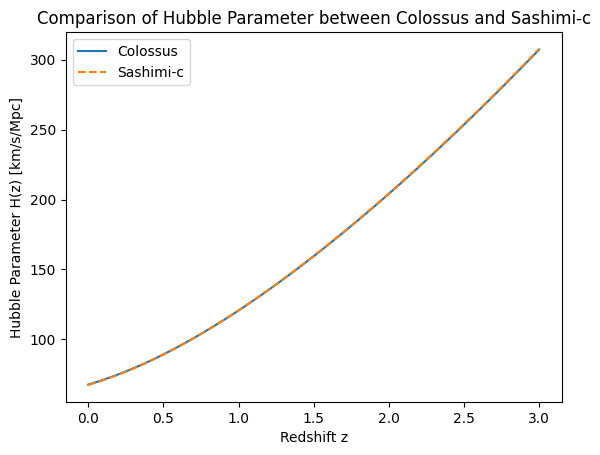

In [2]:
# test consistency of hubble parameter
z = np.linspace(0, 3, 100)
hubble_colossus = cosmo_colossus.Hz(z)  # Hubble parameter at z=0.5
hubble_sashimi = cosmo_sashimi.Hubble(z) # Hubble parameter at z=0.5
hubble_sashimi /= (u.km/u.s/u.Mpc)
plt.plot(z, hubble_colossus, label='Colossus')
plt.plot(z, hubble_sashimi, '--', label='Sashimi-c')
plt.xlabel('Redshift z')
plt.ylabel('Hubble Parameter H(z) [km/s/Mpc]')
plt.legend()
plt.title('Comparison of Hubble Parameter between Colossus and Sashimi-c')
plt.show()

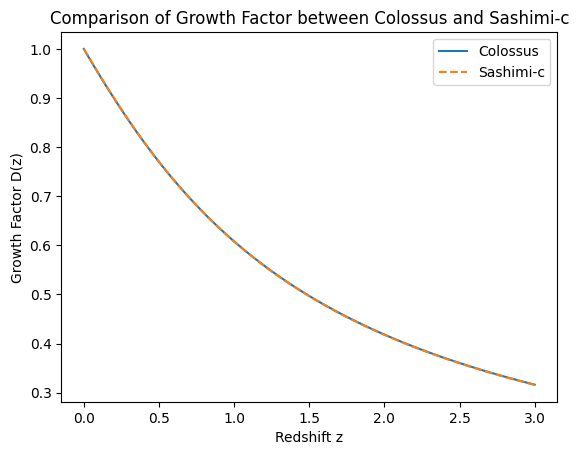

In [3]:
# test consistency of growth factor
z = np.linspace(0, 3, 100)
growth_colossus = cosmo_colossus.growthFactor(z)
growth_sashimi = cosmo_sashimi.growthD(z)
plt.plot(z, growth_colossus, label='Colossus')
plt.plot(z, growth_sashimi, '--', label='Sashimi-c')
plt.xlabel('Redshift z')
plt.ylabel('Growth Factor D(z)')
plt.legend()
plt.title('Comparison of Growth Factor between Colossus and Sashimi-c')
plt.show()

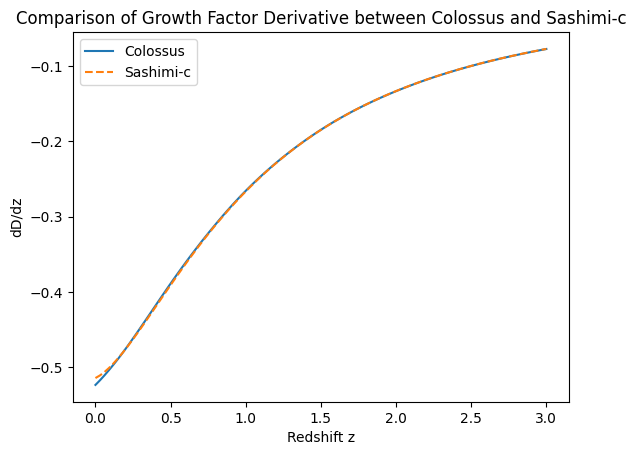

In [4]:
# test consistency of growth factor derivative
z = np.linspace(0, 3, 100)
dgrowth_colossus = cosmo_colossus.growthFactor(z=z, derivative=1)
dgrowth_sashimi = cosmo_sashimi.dDdz(z)
plt.plot(z, dgrowth_colossus, label='Colossus')
plt.plot(z, dgrowth_sashimi, '--', label='Sashimi-c')
plt.xlabel('Redshift z')
plt.ylabel('dD/dz')
plt.legend()
plt.title('Comparison of Growth Factor Derivative between Colossus and Sashimi-c')
plt.show()

In [5]:
# test consistency of sigma
z = np.linspace(0, 3, 100)
M0 = 1e12  # Solar masses
R = cosmo_colossus.lagrangianR(M0)  # Lagrangian radius in Mpc/h
sigma_colossus = cosmo_colossus.sigma(M0, z)

AttributeError: 'Cosmology' object has no attribute 'lagrangianR'

In [ ]:
import sashimi_c
import sashimi_c_v2

z = np.linspace(0, 3, 100)
M0 = 1e12  # Solar masses
%timeit obs = sashimi_c.subhalo_observables(1e12)
%timeit obs = sashimi_c_v2.subhalo_observables(1e12)


In [4]:
from astropy.units import Quantity
import numpy as np

%timeit q = Quantity(np.linspace(0, 10, 100), 'Mpc')
%timeit q = np.array(np.linspace(0, 10, 100)) 

q = Quantity(np.linspace(0, 10, 100), 'Mpc')
%timeit q * q
q = np.array(np.linspace(0, 10, 100))
%timeit q * q

9.8 μs ± 121 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
6.3 μs ± 7.13 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
18.9 μs ± 213 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
458 ns ± 1.75 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [3]:
import sashimi_c as v1
import numpy as np
import matplotlib.pyplot as plt

M = np.logspace(6, 15, 1000)  # Solar masses
z = 0
cosmo = v1.halo_model()
dsdm_func = cosmo.dsdm
# cosmo = v.cosmology()
# dsdm_func = cosmo.dsdm
# s = cosmo.Svar(M, z)  # Variance at redshift z
dsdm = dsdm_func(M, z)  # Derivative of variance with respect to mass
print(f"Using {v1.__name__}:")
%timeit dsdm_func(M, z)


Using sashimi_c:
261 μs ± 568 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
261 μs ± 568 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [3]:
import sashimi_c_v2 as v2
import jax.numpy as jnp
from jax import grad, jit, vmap



M = jnp.logspace(6, 15, 1000)  # Solar masses
z = 0
cosmo = v2.cosmology()
dsdm_jax_func = jit(vmap(cosmo.dsdm_jax, in_axes=(0, None)))
# dsdm = dsdm_func(M, z)  # Derivative of variance with respect to mass
print(f"Using {v2.__name__}:")
%timeit dsdm_jax_func(M, z).block_until_ready()
print()


Using sashimi_c_v2:
93.2 μs ± 2.49 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)

93.2 μs ± 2.49 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)



In [16]:
import sashimi_c_v2 as v2
import jax.numpy as jnp
from jax import grad, jit, vmap



M = jnp.logspace(6, 15, 10000)  # Solar masses
z = 0.0
z = jnp.broadcast_to(z, M.shape)
cosmo = v2.cosmology()
dsdm_native_func = jit(vmap(cosmo.dsdm_native))
# dsdm = dsdm_func(M, z)  # Derivative of variance with respect to mass
print(f"Using {v2.__name__}:")
%timeit dsdm_native_func(M, z).block_until_ready()
print()


Using sashimi_c_v2:
79.2 μs ± 2.14 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)

79.2 μs ± 2.14 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)



In [19]:
import sashimi_c_v2 as v2
import jax.numpy as jnp
from jax import grad, jit, vmap



M = jnp.logspace(6, 15, 10000)  # Solar masses
z = 0
M,z = jnp.broadcast_arrays(M,z)
cosmo = v2.cosmology()
# dsdm_native_func = jit(vmap(cosmo.dsdm_native, in_axes=(0, None)))
dsdm_native_func = jit(vmap(cosmo.dsdm_native))
# dsdm = dsdm_func(M, z)  # Derivative of variance with respect to mass
print(f"Using {v2.__name__}:")
%timeit dsdm_native_func(M, z).block_until_ready()
print()


Using sashimi_c_v2:
80 μs ± 800 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)

80 μs ± 800 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)



In [21]:
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap
import sashimi_c_v2


cosmo = sashimi_c_v2.Cosmology()
M = jnp.logspace(6, 15, 100)
z = 0.0
dsdm_jax = cosmo.dsdm(M, z,method='jax')
dsdm_native = cosmo.dsdm(M, z,method='native')
rerr = jnp.abs((dsdm_jax - dsdm_native)/dsdm_native)
plt.loglog(M,rerr)

AttributeError: 'Cosmology' object has no attribute 'dsdm'

In [34]:
import numpy as np
from astropy.modeling.physical_models import NFW
from astropy.cosmology import Planck18
from sashimi_c import halo_model

mdl = halo_model()
mdl.Mvir_from_M200

rhoc = Planck18.critical_density0

m = np.array([1,2,3])
c = np.array([10,20,30])
nfw_ast = NFW(m,c,0,massfactor="virial")
nfw_ast()

ValueError: Missing input arguments - expected 1, got 0

<Quantity 8.59881426e-30 g / cm3>